In [12]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [13]:
def integrate(f, xt, t, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    dyn: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt, t)
    k2 = dt * f(xt+k1/2., t + dt/2.)
    k3 = dt * f(xt+k2/2., t + dt/2.)
    k4 = dt * f(xt+k3, t + dt)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        t = tvec[i]
        xtraj[:,i]=integrate(f,x,t,dt)
        x = np.copy(xtraj[:,i])
    return xtraj, tvec

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1545367/646551329.py:2: SyntaxWarning: invalid escape sequence '\d'
  """
/tmp/ipykernel_1545367/646551329.py:31: SyntaxWarning: invalid escape sequence '\d'
  """


In [14]:
t, G, m1, m2, r1, r2, tau = sym.symbols(r't, G, m_1, m_2, r_1, r_2, \tau_m')
G = r2 / r1
J_1 = 1/2 * m1 * r1**2
J_2 = 1/2 * m2 * r2**2

th1 = sym.Function(r'\theta_1')(t)
th2 = sym.Function(r'\theta_2')(t)
q = sym.Matrix([th1, th2])
q_dot = q.diff(t)
q_ddot = q_dot.diff(t)

q_dot[1] = q_dot[0] / G
KE = 1/2 * J_1 * q_dot[0]**2 + 1/2 * J_2 * q_dot[1]**2

display(KE)

# Ignoring potential energy for now, as we are only interested in the dynamics of the system
L = KE

dLdq = L.diff(q[0])
dLdq_dot = L.diff(q_dot[0])
d_dLdq_dot_dt = dLdq_dot.diff(t)

lhs = d_dLdq_dot_dt - dLdq
display(lhs)
rhs = tau
display(rhs)

eqn = sym.Eq(lhs, rhs)
soln = sym.solve(eqn, q_ddot[0])
print("The solution for the acceleration of the first pulley:")
display(soln[0])

print("The solution for the acceleration of the second pulley:")
soln2 = soln[0] / G
display(soln2)


0.25*m_1*r_1**2*Derivative(\theta_1(t), t)**2 + 0.25*m_2*r_1**2*Derivative(\theta_1(t), t)**2

0.5*m_1*r_1**2*Derivative(\theta_1(t), (t, 2)) + 0.5*m_2*r_1**2*Derivative(\theta_1(t), (t, 2))

\tau_m

The solution for the acceleration of the first pulley:


2.0*\tau_m/(r_1**2*(m_1 + m_2))

The solution for the acceleration of the second pulley:


2.0*\tau_m/(r_1*r_2*(m_1 + m_2))

In [15]:
thetaddot1_num = sym.lambdify((m1, m2, r1, r2, tau), soln[0])

Shape of traj:  (2, 10000)


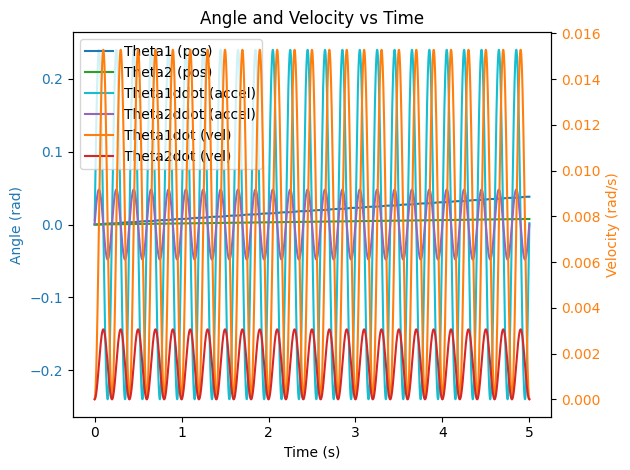

In [16]:
def dyn(s, t):
    """
    System dynamics function (extended)

    Parameters
    ============
    s: NumPy array
        s = [theta1, theta1dot] is the extended system
        state vector, includng the position and
        the velocity of the particle

    Return
    ============
    sdot: NumPy array
        time derivative of input state vector,
        sdot = [theta1dot, theta1ddot]
    """
    # Call the lambdified functions with the current state s
    tau_val = tau_amp * np.sin(2 * np.pi * freq * t)
    thetaddot1_val = thetaddot1_num(m1,m2,r1,r2,tau_val)

    # Return the derivatives
    return np.array([s[1], thetaddot1_val])

# define initial state
# Theta1 = 0, Theta_dot1 = 0
s0 = np.array([0,0])
m1, m2, r1, r2 = 1, 1, 1, 5
tau_amp = 0.24 # Torque amplitude (Nm)
freq = 5.0

timestep = 0.0005

# freq = np.linspace(0, 2, 100)

traj1, time = simulate(dyn, s0, [0, 5], timestep, integrate)
accel1 = np.gradient(traj1[1, :], timestep)
print('\033[1mShape of traj: \033[0m', traj1.shape)

traj2 = np.array([traj1[0, :] / (r2/r1), traj1[1, :] / (r2/r1)])
accel2 = np.gradient(traj2[1, :], timestep)

# time = np.linspace(0,5,traj1.shape[1])

fig, ax1 = plt.subplots()

# Plot Position (Theta1) on the left y-axis
ax1.plot(time, traj1[0, :], color='tab:blue', label='Theta1 (pos)')
ax1.plot(time, traj2[0, :], color='tab:green', label='Theta2 (pos)')
ax1.plot(time, accel1, color='tab:cyan', label='Theta1ddot (accel)')
ax1.plot(time, accel2, color='tab:purple', label='Theta2ddot (accel)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angle (rad)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(time, traj1[1, :], color='tab:orange', label='Theta1dot (vel)')
ax2.plot(time, traj2[1, :], color='tab:red', label='Theta2dot (vel)')
ax2.set_ylabel('Velocity (rad/s)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combine the handles and labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Angle and Velocity vs Time')
fig.tight_layout()
plt.show()

In [17]:
# Isolate the last 2 seconds (assuming freq = 5.0 Hz, 2s = 10 full cycles)
steady_state_time = 2.0 
tail_idx = time > (time[-1] - steady_state_time)

time_tail = time[tail_idx]
pos_tail = traj1[0, tail_idx]
vel_tail = traj1[1, tail_idx]
accel_tail = accel1[tail_idx]

# Generate the ideal input torque for this exact time tail
input_torque = tau_amp * np.sin(2 * np.pi * freq * time_tail)

def extract_bode_data(time_array, input_wave, output_wave, frequency, timestep):
    """Detrends output, calculates amplitude, and finds phase shift in degrees."""
    # 1. Remove DC offset / ramp drift
    out_detrended = signal.detrend(output_wave)
    
    # 2. Amplitude
    amplitude = (np.max(out_detrended) - np.min(out_detrended)) / 2.0
    
    # 3. Phase Shift (Cross-Correlation)
    correlation = signal.correlate(out_detrended, input_wave, mode='full')
    lags = signal.correlation_lags(len(out_detrended), len(input_wave), mode='full')
    
    # Find the lag index of maximum correlation
    lag_idx = lags[np.argmax(correlation)]
    
    # Convert lag index to time delay, then to degrees
    time_delay = lag_idx * timestep
    phase_deg = (time_delay * frequency * 360) % 360
    
    # Keep phase bounded between 180 and -180
    if phase_deg > 180:
        phase_deg -= 360
        
    return amplitude, phase_deg

# Extract Position Data
pos_amp, pos_phase = extract_bode_data(time_tail, input_torque, pos_tail, freq, timestep)
print(f"Position     -> Amplitude: {pos_amp:.4f} rad,   Phase: {pos_phase:.1f} deg")

# Extract Velocity Data
vel_amp, vel_phase = extract_bode_data(time_tail, input_torque, vel_tail, freq, timestep)
print(f"Velocity     -> Amplitude: {vel_amp:.4f} rad/s, Phase: {vel_phase:.1f} deg")

# Extract Acceleration Data
accel_amp, accel_phase = extract_bode_data(time_tail, input_torque, accel_tail, freq, timestep)
print(f"Acceleration -> Amplitude: {accel_amp:.4f} rad/s^2, Phase: {accel_phase:.1f} deg")

Position     -> Amplitude: 0.0003 rad,   Phase: 179.1 deg
Velocity     -> Amplitude: 0.0077 rad/s, Phase: 88.2 deg
Acceleration -> Amplitude: 0.2595 rad/s^2, Phase: -0.9 deg


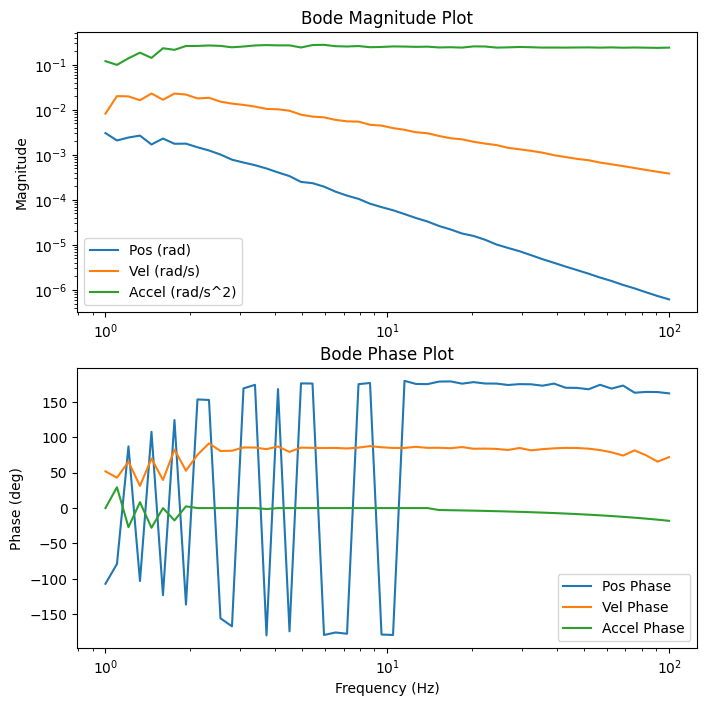

In [18]:
# 1. Setup Sweep Parameters
freq_sweep = np.logspace(0, 2, 50)  # 50 points from 1 Hz to 100 Hz
timestep = 0.0005                  # Finer step for 100 Hz stability
amps_pos, phases_pos = [], []
amps_vel, phases_vel = [], []
amps_accel, phases_accel = [], []

# 2. Run Frequency Sweep
for f in freq_sweep:
    # Update global frequency for the dyn function
    freq = f 
    
    # Run simulation
    traj1, time = simulate(dyn, s0, [0, 2.0], timestep, integrate)
    accel1 = np.gradient(traj1[1, :], timestep)
    
    # 3. Extract Steady-State Data (last 0.5 seconds is sufficient)
    tail_idx = time > (time[-1] - 0.5)
    input_wave = tau_amp * np.sin(2 * np.pi * freq * time[tail_idx])
    
    # 4. Process each output type
    a_p, p_p = extract_bode_data(time[tail_idx], input_wave, traj1[0, tail_idx], freq, timestep)
    a_v, p_v = extract_bode_data(time[tail_idx], input_wave, traj1[1, tail_idx], freq, timestep)
    a_a, p_a = extract_bode_data(time[tail_idx], input_wave, accel1[tail_idx], freq, timestep)
    
    # Append to lists
    amps_pos.append(a_p); phases_pos.append(p_p)
    amps_vel.append(a_v); phases_vel.append(p_v)
    amps_accel.append(a_a); phases_accel.append(p_a)

# 5. Plot Bode Data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.loglog(freq_sweep, amps_pos, label='Pos (rad)')
ax1.loglog(freq_sweep, amps_vel, label='Vel (rad/s)')
ax1.loglog(freq_sweep, amps_accel, label='Accel (rad/s^2)')
ax1.set_ylabel('Magnitude')
ax1.legend()
ax1.set_title('Bode Magnitude Plot')

ax2.semilogx(freq_sweep, phases_pos, label='Pos Phase')
ax2.semilogx(freq_sweep, phases_vel, label='Vel Phase')
ax2.semilogx(freq_sweep, phases_accel, label='Accel Phase')
ax2.set_ylabel('Phase (deg)')
ax2.set_xlabel('Frequency (Hz)')
ax2.legend()
ax2.set_title('Bode Phase Plot')
plt.show()